In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"
from transformers import AutoModelForCausalLM, AutoTokenizer

model_path = "/home/lym/data1/LLM-model/meta-llama/Meta-Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    torch_dtype="auto",
    attn_implementation="eager",
)
model.eval()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
    (rotary_

Number of samples with span length between 300 and 350: 16
Sample 0: span length = 306
  Layer 12 Head 26: sink: 0.3805, ideal: 0.5378, other: 0.0817


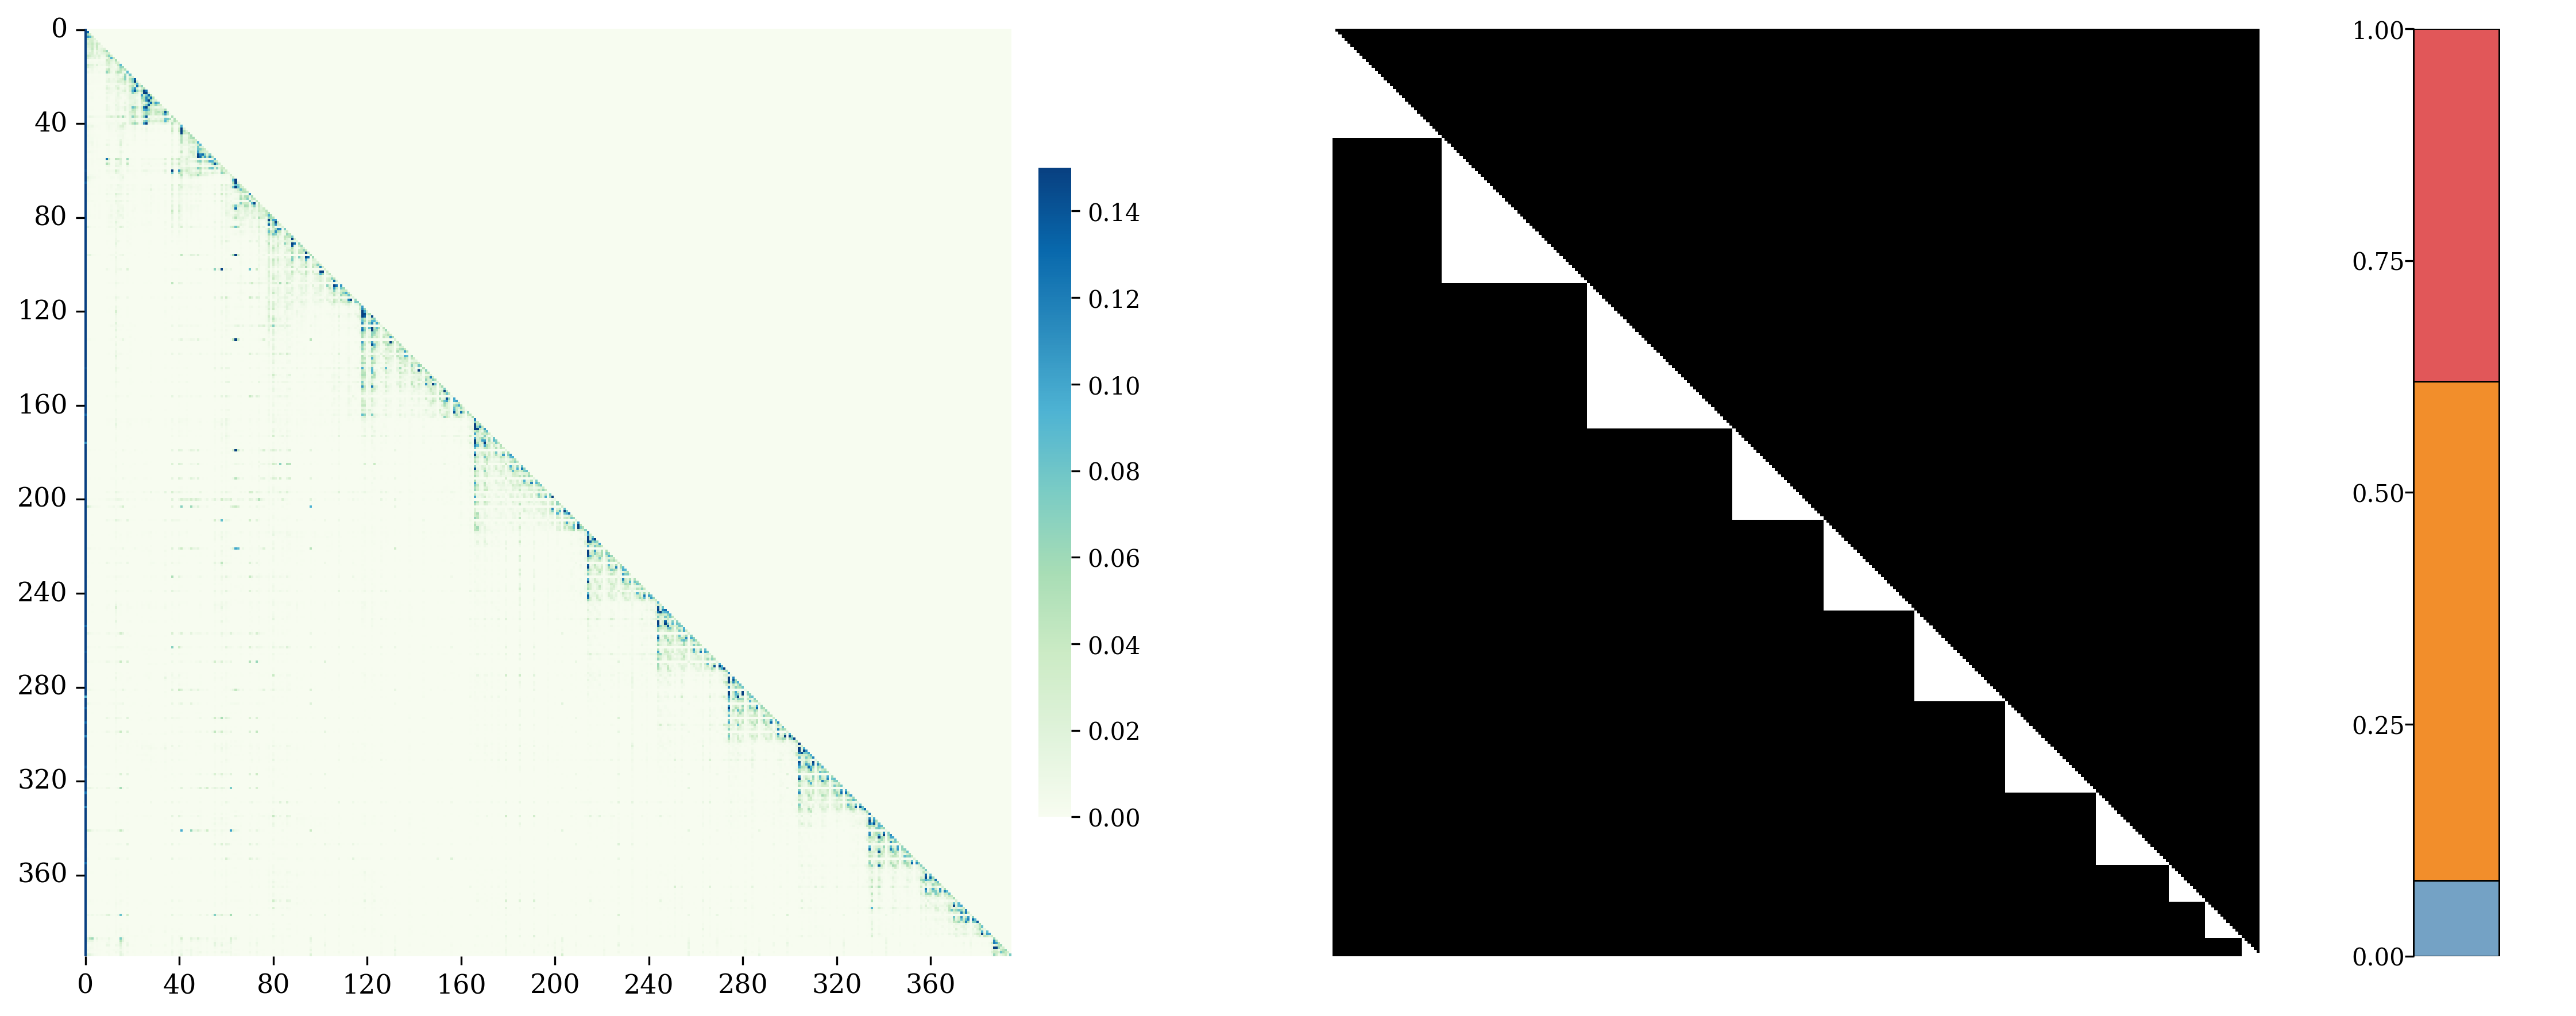

  Selected head: 26, sink: 0.3805, ideal: 0.5378, other: 0.0817


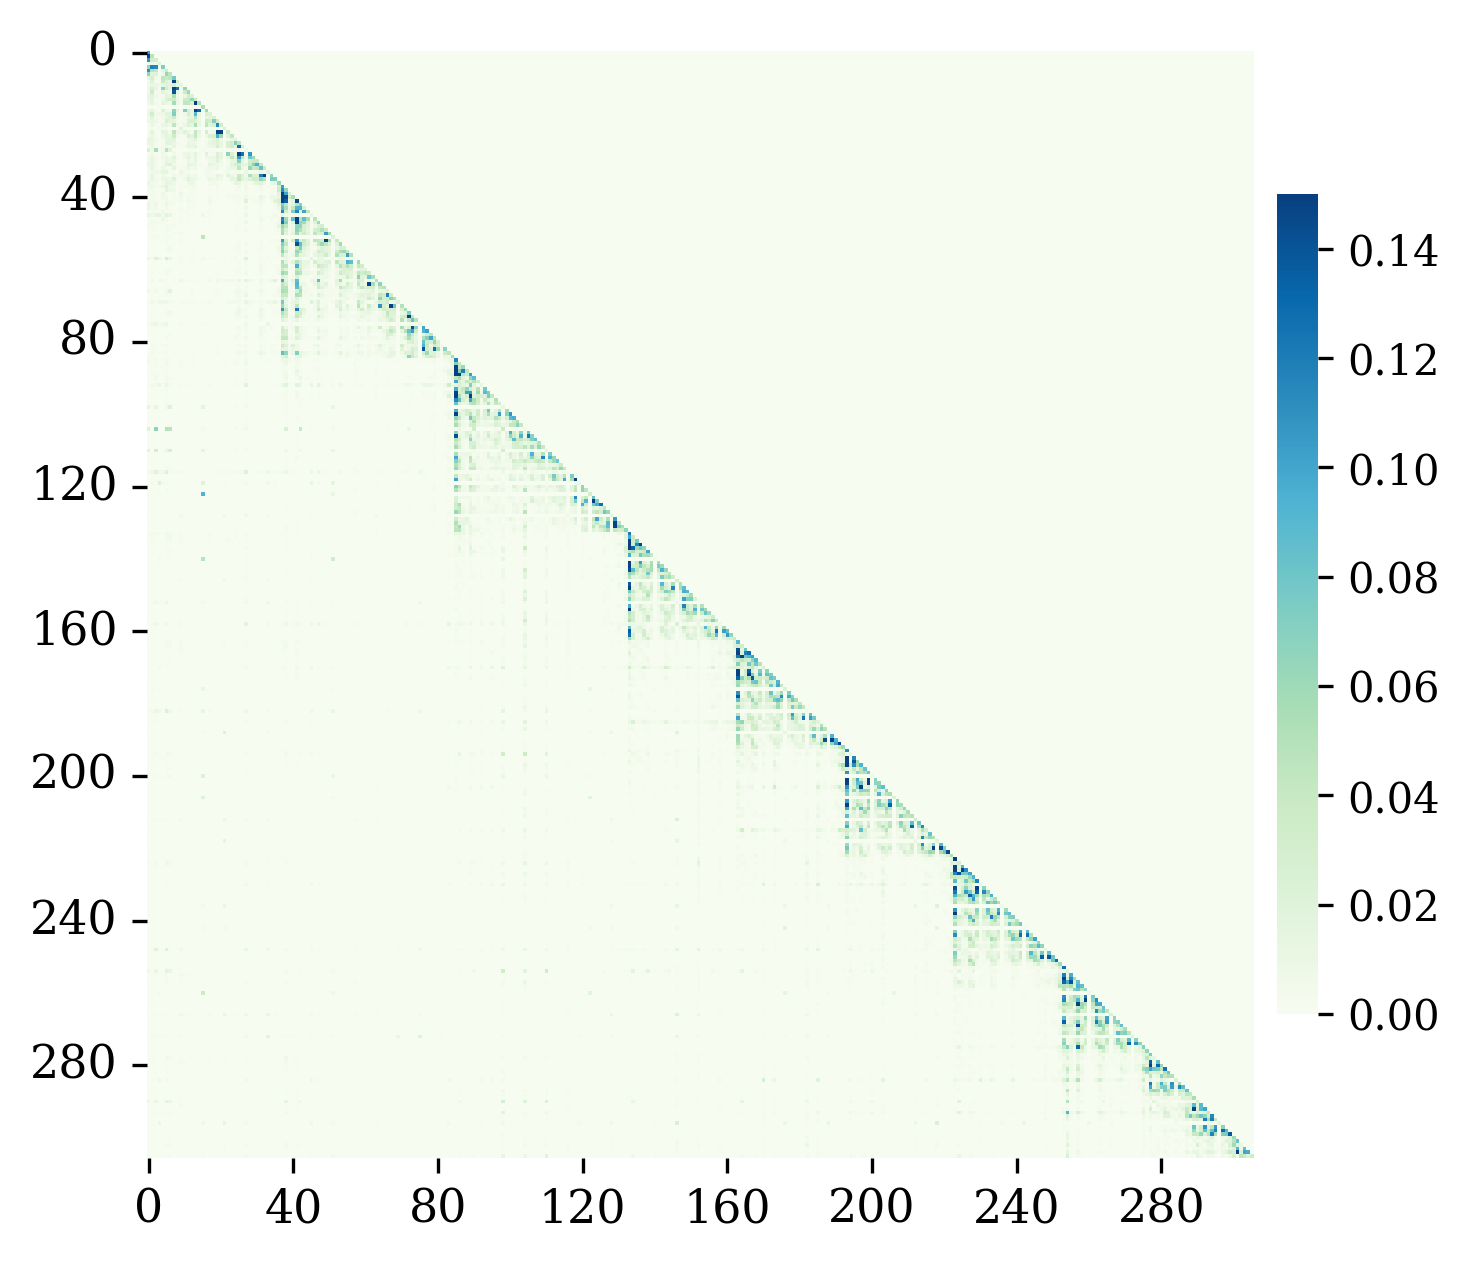

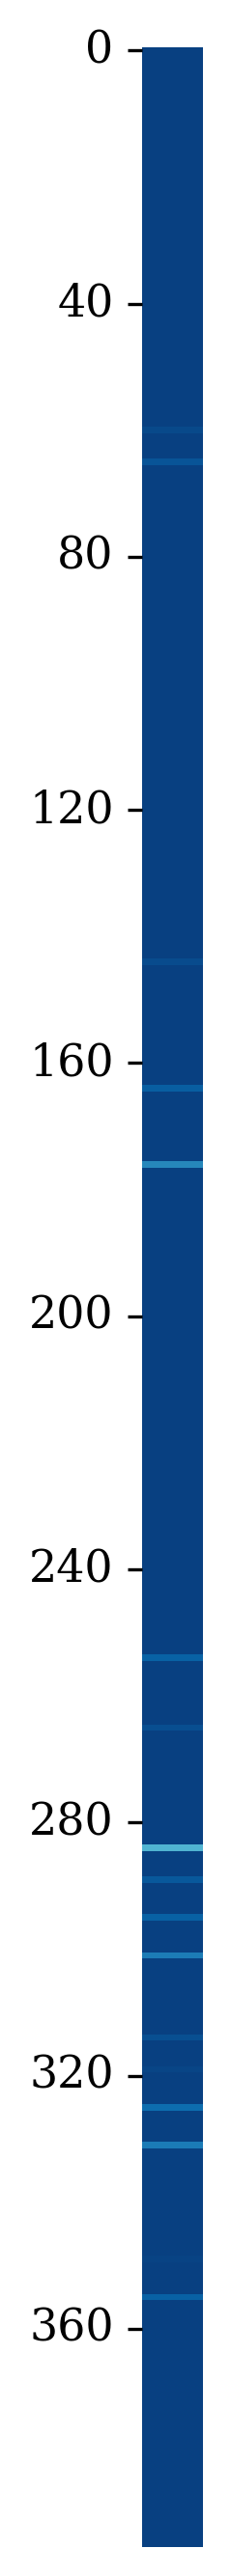

In [82]:
import sys
sys.path.append("/home/lym/LLM-Research/Attention/Graph_Attention/SLASH/src/slash")
import torch
import numpy as np
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from utils import (
    get_token_spans,
    compute_global_span,
    build_local_spans,
    build_sawtooth_mask,
)

# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 16, and the edges are: (0, 9) (0, 3) (0, 5) (1, 6) (1, 4) (1, 9) (2, 4) (2, 7) (3, 13) (3, 4) (3, 14) (3, 11) (3, 8) (4, 12) (4, 8) (4, 14) (4, 6) (5, 6) (5, 13) (5, 8) (5, 10) (5, 9) (6, 11) (6, 15) (6, 8) (7, 14) (7, 15) (9, 13) (9, 16) (10, 16) (10, 15) (10, 13) (11, 13) (12, 15) (13, 15) (14, 16). Is there a cycle in this graph?"
# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 11, and the edges are: (0, 6) (0, 2) (0, 3) (0, 10) (0, 7) (0, 11) (1, 6) (1, 3) (1, 2) (1, 4) (1, 11) (1, 7) (1, 8) (1, 9) (2, 4) (2, 7) (2, 6) (2, 8) (2, 10) (2, 11) (2, 9) (2, 5) (3, 11) (3, 5) (3, 6) (3, 4) (3, 8) (4, 11) (4, 7) (4, 10) (4, 9) (4, 6) (5, 10) (5, 7) (5, 9) (5, 11) (5, 8) (6, 11) (6, 9) (6, 7) (6, 10) (6, 8) (7, 8) (7, 11) (7, 9) (7, 10) (8, 9) (8, 10) (9, 11) (9, 10) (10, 11). Is there a cycle in this graph?"
# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 11, and the edges are: (0, 3) (0, 10) (0, 7) (0, 5) (0, 8) (0, 11) (0, 2) (0, 1) (0, 4) (1, 6) (1, 9) (1, 2) (1, 4) (1, 7) (1, 8) (1, 5) (1, 10) (2, 5) (2, 9) (2, 10) (2, 7) (2, 3) (2, 8) (2, 11) (3, 10) (3, 4) (3, 6) (3, 5) (3, 7) (4, 9) (4, 5) (4, 11) (4, 10) (4, 6) (4, 7) (5, 8) (5, 10) (5, 11) (5, 6) (5, 9) (6, 11) (6, 7) (6, 9) (7, 11) (7, 8) (7, 9) (7, 10) (8, 9) (8, 10) (9, 11) (9, 10) (10, 11). Is there a cycle in this graph?"
# sample_input = "Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 14, and the edges are: (0, 9) (0, 4) (0, 8) (0, 10) (0, 7) (0, 1) (0, 13) (0, 14) (0, 6) (0, 2) (0, 3) (0, 5) (0, 12) (1, 4) (1, 9) (1, 14) (1, 3) (1, 2) (1, 12) (1, 8) (1, 11) (1, 6) (1, 13) (1, 7) (1, 5) (1, 10) (2, 9) (2, 12) (2, 14) (2, 4) (2, 11) (2, 7) (2, 5) (2, 6) (2, 8) (2, 13) (2, 10) (3, 8) (3, 5) (3, 12) (3, 6) (3, 11) (3, 9) (3, 10) (3, 13) (3, 7) (3, 4) (3, 14) (4, 7) (4, 10) (4, 9) (4, 8) (4, 12) (4, 6) (4, 13) (4, 14) (4, 11) (5, 8) (5, 12) (5, 7) (5, 10) (5, 14) (5, 9) (5, 11) (5, 6) (5, 13) (6, 8) (6, 9) (6, 13) (6, 10) (6, 12) (6, 7) (6, 14) (6, 11) (7, 12) (7, 9) (7, 8) (7, 11) (7, 10) (7, 14) (7, 13) (8, 13) (8, 10) (8, 9) (8, 11) (8, 14) (8, 12) (9, 10) (9, 13) (9, 11) (10, 11) (10, 12) (10, 13) (10, 14) (11, 13) (11, 12) (11, 14) (12, 13) (12, 14). Is there a cycle in this graph?"

def plot_heatmap(attn_matrix, ideal_mask, sample_idx, layer, head, sink_ratio=None, ideal_ratio=None, other_ratio=None, savepath=None):
    mpl.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "legend.fontsize": 9,
    })

    fig, (ax1, ax2, ax3) = plt.subplots(
        1, 3, figsize=(16, 6), 
        gridspec_kw={'width_ratios': [1.3, 1, 0.2]},
        dpi=300
    )

    vmax = 0.15
    vmin = 0.0

    sns.heatmap(
        attn_matrix,
        cmap="GnBu",
        vmin=vmin, vmax=vmax,
        cbar=True,
        cbar_kws={"shrink": 0.7, "pad": 0.02, "format": "%.2f"},
        xticklabels=40, yticklabels=40,
        ax=ax1,
        square=True
    )
    # ax1.set_title(f"Attention — sample {sample_idx}, L{layer} H{head}")
    ax1.tick_params(axis='both', which='major', labelsize=11, labelrotation=0)

    sns.heatmap(
        ideal_mask,
        cmap="gray",
        cbar=False,
        ax=ax2,
        xticklabels=False, yticklabels=False,
        square=True
    )
    # ax2.set_title("Ideal sawtooth")
    ax2.axis('off')   # 不绘制坐标轴刻度与框线

    # 比例条（使用累积 bottom，移除未使用的 bottoms 变量）
    if sink_ratio is not None and ideal_ratio is not None and other_ratio is not None:
        ratios = [other_ratio, ideal_ratio, sink_ratio]
        colors = ["#74a2c5", "#f28e2b", "#e15759"] 
        labels = ['other', 'ideal', 'sink']

        bottom_acc = 0.0
        bar_x = 0
        bar_width = 0.25 
        for r, c in zip(ratios, colors):
            ax3.bar(bar_x, r, bottom=bottom_acc, width=bar_width, color=c, edgecolor='black', linewidth=0.7, align='center')
            bottom_acc += r

        ax3.set_ylim(0, 1)
        ax3.set_xlim(-0.3, 0.3)
        ax3.set_xticks([])
        yticks = np.linspace(0.0, 1.0, 5)
        ax3.set_yticks(yticks)
        for name, spine in ax3.spines.items():
            spine.set_visible(name in ['left'])  # 显示左侧和底部边框
        
        # ax3.spines['bottom'].set_linewidth(0.6)  # 设置底部边框的线宽
        # ax3.spines['bottom'].set_color('black')
        ax3.spines['left'].set_linewidth(0.6)
        ax3.spines['left'].set_color('black')
        ax3.spines['left'].set_position(('data', -0.125))  # 将左侧刻度线移动到 x=-0.1

        # ax3.tick_params(axis='y', which='major', length=6, pad=4)
        ax3.tick_params(axis='y', which='major', pad=0)
        ax3.yaxis.set_ticks_position('left')
        # ax3.xaxis.set_visible(False)

        # 去掉多余横向空白（比 set_xlim 更稳健）
        # ax3.margins(x=0.02)

        # 如果需要透明背景（用于导出），取消下面一行注释：
        # ax3.patch.set_alpha(0.0)
        # 否则显式设为白色以避免“灰边”
        ax3.set_facecolor('white')
    else:
        ax3.axis('off')

    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()


def attn_ratio_global(full_attn, roi_start, roi_end, ideal_mask):
    # 只用 ROI 行，所有列
    roi_rows = full_attn[roi_start:roi_end, :]
    total = roi_rows.sum()
    if total == 0:
        return 0.0, 0.0, 0.0

    # 1. 第一列（全局）
    first_col_sum = roi_rows[:, 0].sum()

    # 2. 除第一列外且 ideal_mask==1（全局）
    ideal_sum = roi_rows[:, roi_start:roi_end+1].sum()

    # 3. 其他（全局）
    other_sum = total - first_col_sum - ideal_sum

    return first_col_sum / total, ideal_sum / total, other_sum / total


def plot_roi_and_first_column_zoom(full_attn, g_start, g_end,
                                   cmap="GnBu", vmax=0.15,
                                   roi_figsize=(5, 5), sink_figsize=(0.9, 9),
                                   cb_fraction=0.035, cb_aspect=20,
                                   save_roi=None, save_sink=None):
    """
    使用 seaborn.heatmap 绘制（行为与 notebook 中 full_attn/roi 一致）：
      - 左：ROI 热力图（sns）
      - 右：full_attn 第一列的放大图（仅第一列，sns）
    返回 (fig_roi, fig_sink, ax_roi, ax_sink)
    """
    # ROI
    roi = full_attn[g_start:g_end+1, g_start:g_end+1]
    fig_roi, ax_roi = plt.subplots(figsize=roi_figsize, dpi=300)
    sns.heatmap(
        roi,
        ax=ax_roi,
        cmap=cmap,
        vmin=0.0, vmax=vmax,
        square=True,
        cbar=True,
        cbar_kws={"fraction": cb_fraction, "pad": 0.02, "aspect": cb_aspect, "shrink": 0.8, "format": "%.2f"},
        xticklabels=40, yticklabels=40,
    )
    ax_roi.tick_params(axis='both', which='major', labelsize=11, labelrotation=0)
    plt.tight_layout()
    if save_roi:
        fig_roi.savefig(save_roi, bbox_inches="tight", dpi=300, transparent=True)

    # First-column zoom (sns heatmap on a single-column 2D array)
    col = full_attn[:, 0:1]  # keep 2D
    fig_sink, ax_sink = plt.subplots(figsize=sink_figsize, dpi=300)
    sns.heatmap(
        col,
        ax=ax_sink,
        cmap=cmap,
        vmin=0.0, vmax=vmax,
        # square=True,
        cbar=False,
        xticklabels=False,
        yticklabels=40,
    )
    ax_sink.tick_params(axis='y', which='major', labelsize=11, labelrotation=0)
    plt.tight_layout()
    if save_sink:
        fig_sink.savefig(save_sink, bbox_inches="tight", dpi=300, transparent=True)

    return fig_roi, fig_sink, ax_roi, ax_sink

data_path = "/home/lym/data1/Datasets/GraphWiz/GraphInstruct-Test/cycle_test.json"
data = []
with open(data_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

sample_list = []
for item in data:
    spans = get_token_spans(item["input_prompt"], tokenizer)
    g_start, g_end, span_len, spans_sorted = compute_global_span(spans)
    sample_dict = {
        "input_prompt": item["input_prompt"],
        "g_start": g_start,
        "g_end": g_end,
        "span_len": span_len,
        "spans_sorted": spans_sorted
    }
    if span_len > 300 and span_len < 350:
        sample_list.append(sample_dict)
print(f"Number of samples with span length between 300 and 350: {len(sample_list)}")

# layer, head = 12, 24
# layer, head = 12, 25
# layer, head = 12, 17
# layer, head = 12, 18
layer = 12
heads = range(0, 32)
heads = [26]

for i, sample in enumerate(sample_list[1:2]):

    min_other_ratio = 1.0
    min_sink_ratio = None
    min_ideal_ratio = None
    min_head = -1
    min_full_attn = None

    print(f"Sample {i}: span length = {sample['span_len']}")
    enc = tokenizer(
        sample["input_prompt"],
        return_tensors="pt",
        truncation=True,
    ).to(model.device)
    with torch.no_grad():
        out = model(enc.input_ids, output_attentions=True, use_cache=False)
    attn_np = np.stack(
        [a[0].to(torch.float32).detach().cpu().numpy() for a in out.attentions],
        axis=0
    ) 

    local_spans = build_local_spans(sample["g_start"], sample["spans_sorted"])
    ideal_mask = build_sawtooth_mask(sample["span_len"], local_spans)

    for head in heads:
        full_attn = attn_np[layer, head]

        roi_attn = full_attn[sample["g_start"]:sample["g_end"] + 1, sample["g_start"]:sample["g_end"] + 1]
        sink_ratio, ideal_ratio, other_ratio = attn_ratio_global(full_attn, sample["g_start"], sample["g_end"], ideal_mask)
        print(f"  Layer {layer} Head {head}: sink: {sink_ratio:.4f}, ideal: {ideal_ratio:.4f}, other: {other_ratio:.4f}")
        plot_heatmap(full_attn, ideal_mask, i, layer, head, sink_ratio, ideal_ratio, other_ratio)
        if other_ratio < min_other_ratio and head not in []:
            min_other_ratio = other_ratio
            min_head = head
            min_full_attn = full_attn
            min_sink_ratio = sink_ratio
            min_ideal_ratio = ideal_ratio
    print(f"  Selected head: {min_head}, sink: {min_sink_ratio:.4f}, ideal: {min_ideal_ratio:.4f}, other: {min_other_ratio:.4f}")
    # plot_heatmap(min_full_attn, ideal_mask, i, layer, min_head, min_sink_ratio, min_ideal_ratio, min_other_ratio)
    fig_roi, fig_sink, _, _ = plot_roi_and_first_column_zoom(
        full_attn, sample['g_start'], sample['g_end'],
        vmax=0.15,
        # save_roi="roi.png",
        # save_sink="first_column_zoom.png"
    )
    del out, attn_np, full_attn, ideal_mask, roi_attn
    torch.cuda.empty_cache()

In [85]:
# Entropy Figure
import numpy as np

entropy_data_path = "/home/lym/LLM-Research/Attention/Graph_Attention/SLASH/outputs/final_select/select5.2/GraphWiz/Meta-Llama-3.1-8B-Instruct/entropy_results/cycle_entropy_per_layer/cycle_entropy_per_layer.npz"
entropy_data = np.load(entropy_data_path)
print(entropy_data.files)
print(entropy_data["avg_entropy"].shape)
print(entropy_data["count"])

['avg_entropy', 'count']
(32,)
[50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50
 50 50 50 50 50 50 50 50]


Number of samples with span length between 300 and 350: 16
Determine whether or not there is a cycle in an undirected graph. In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. Given a graph, you need to output Yes or No, indicating whether there is a cycle in the graph. Q: The nodes are numbered from 0 to 11, and the edges are: (0, 6) (0, 2) (0, 3) (0, 10) (0, 7) (0, 11) (1, 6) (1, 3) (1, 2) (1, 4) (1, 11) (1, 7) (1, 8) (1, 9) (2, 4) (2, 7) (2, 6) (2, 8) (2, 10) (2, 11) (2, 9) (2, 5) (3, 11) (3, 5) (3, 6) (3, 4) (3, 8) (4, 11) (4, 7) (4, 10) (4, 9) (4, 6) (5, 10) (5, 7) (5, 9) (5, 11) (5, 8) (6, 11) (6, 9) (6, 7) (6, 10) (6, 8) (7, 8) (7, 11) (7, 9) (7, 10) (8, 9) (8, 10) (9, 11) (9, 10) (10, 11). Is there a cycle in this graph?
[320, 15, 11, 220, 21, 8, 320, 15, 11, 220, 17, 8, 320, 15, 11, 220, 18, 8, 320, 15, 11, 220, 605, 8, 320, 15, 11, 220, 22, 8, 320, 15, 11, 220, 806, 8, 320, 16, 11, 220, 21, 8, 320, 16, 11, 220, 18, 8, 320, 16, 11

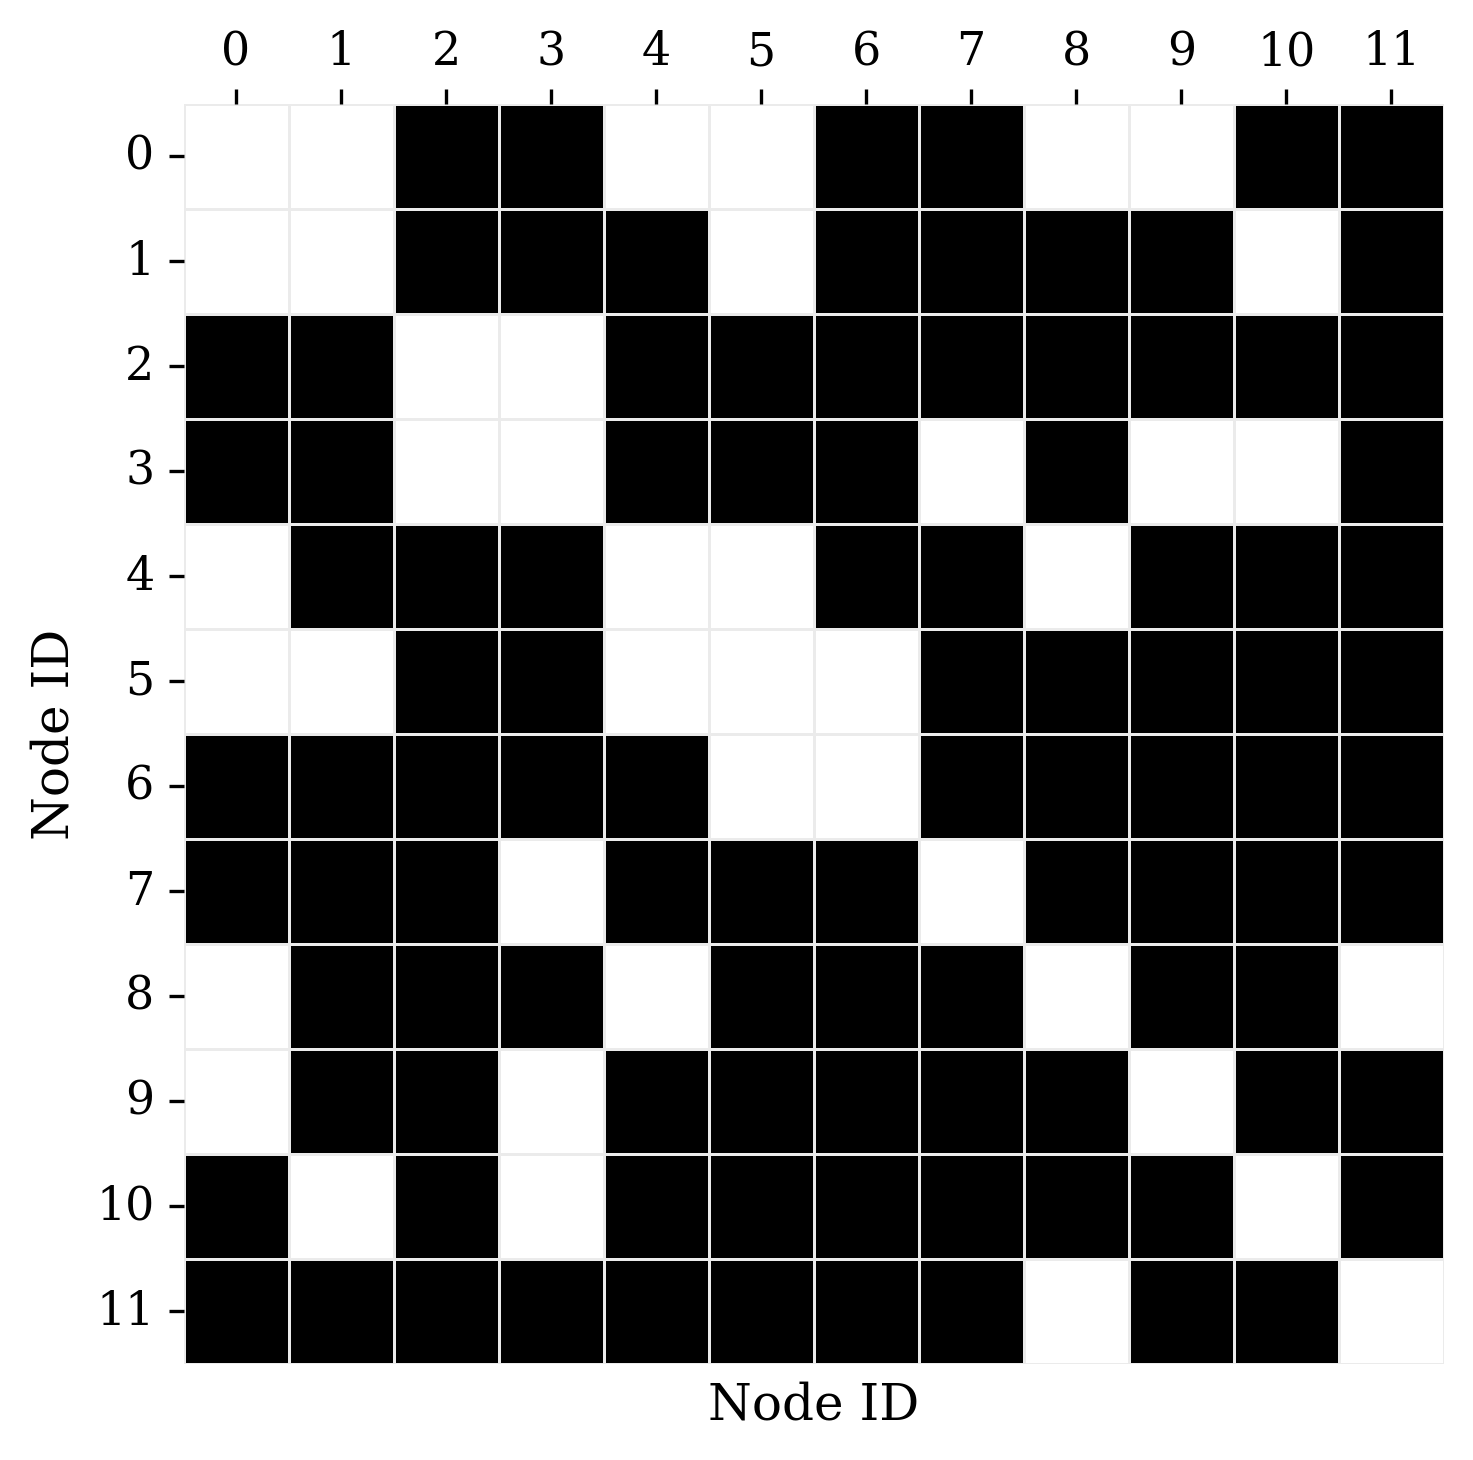

/home/lym/anaconda3/envs/graphllm/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


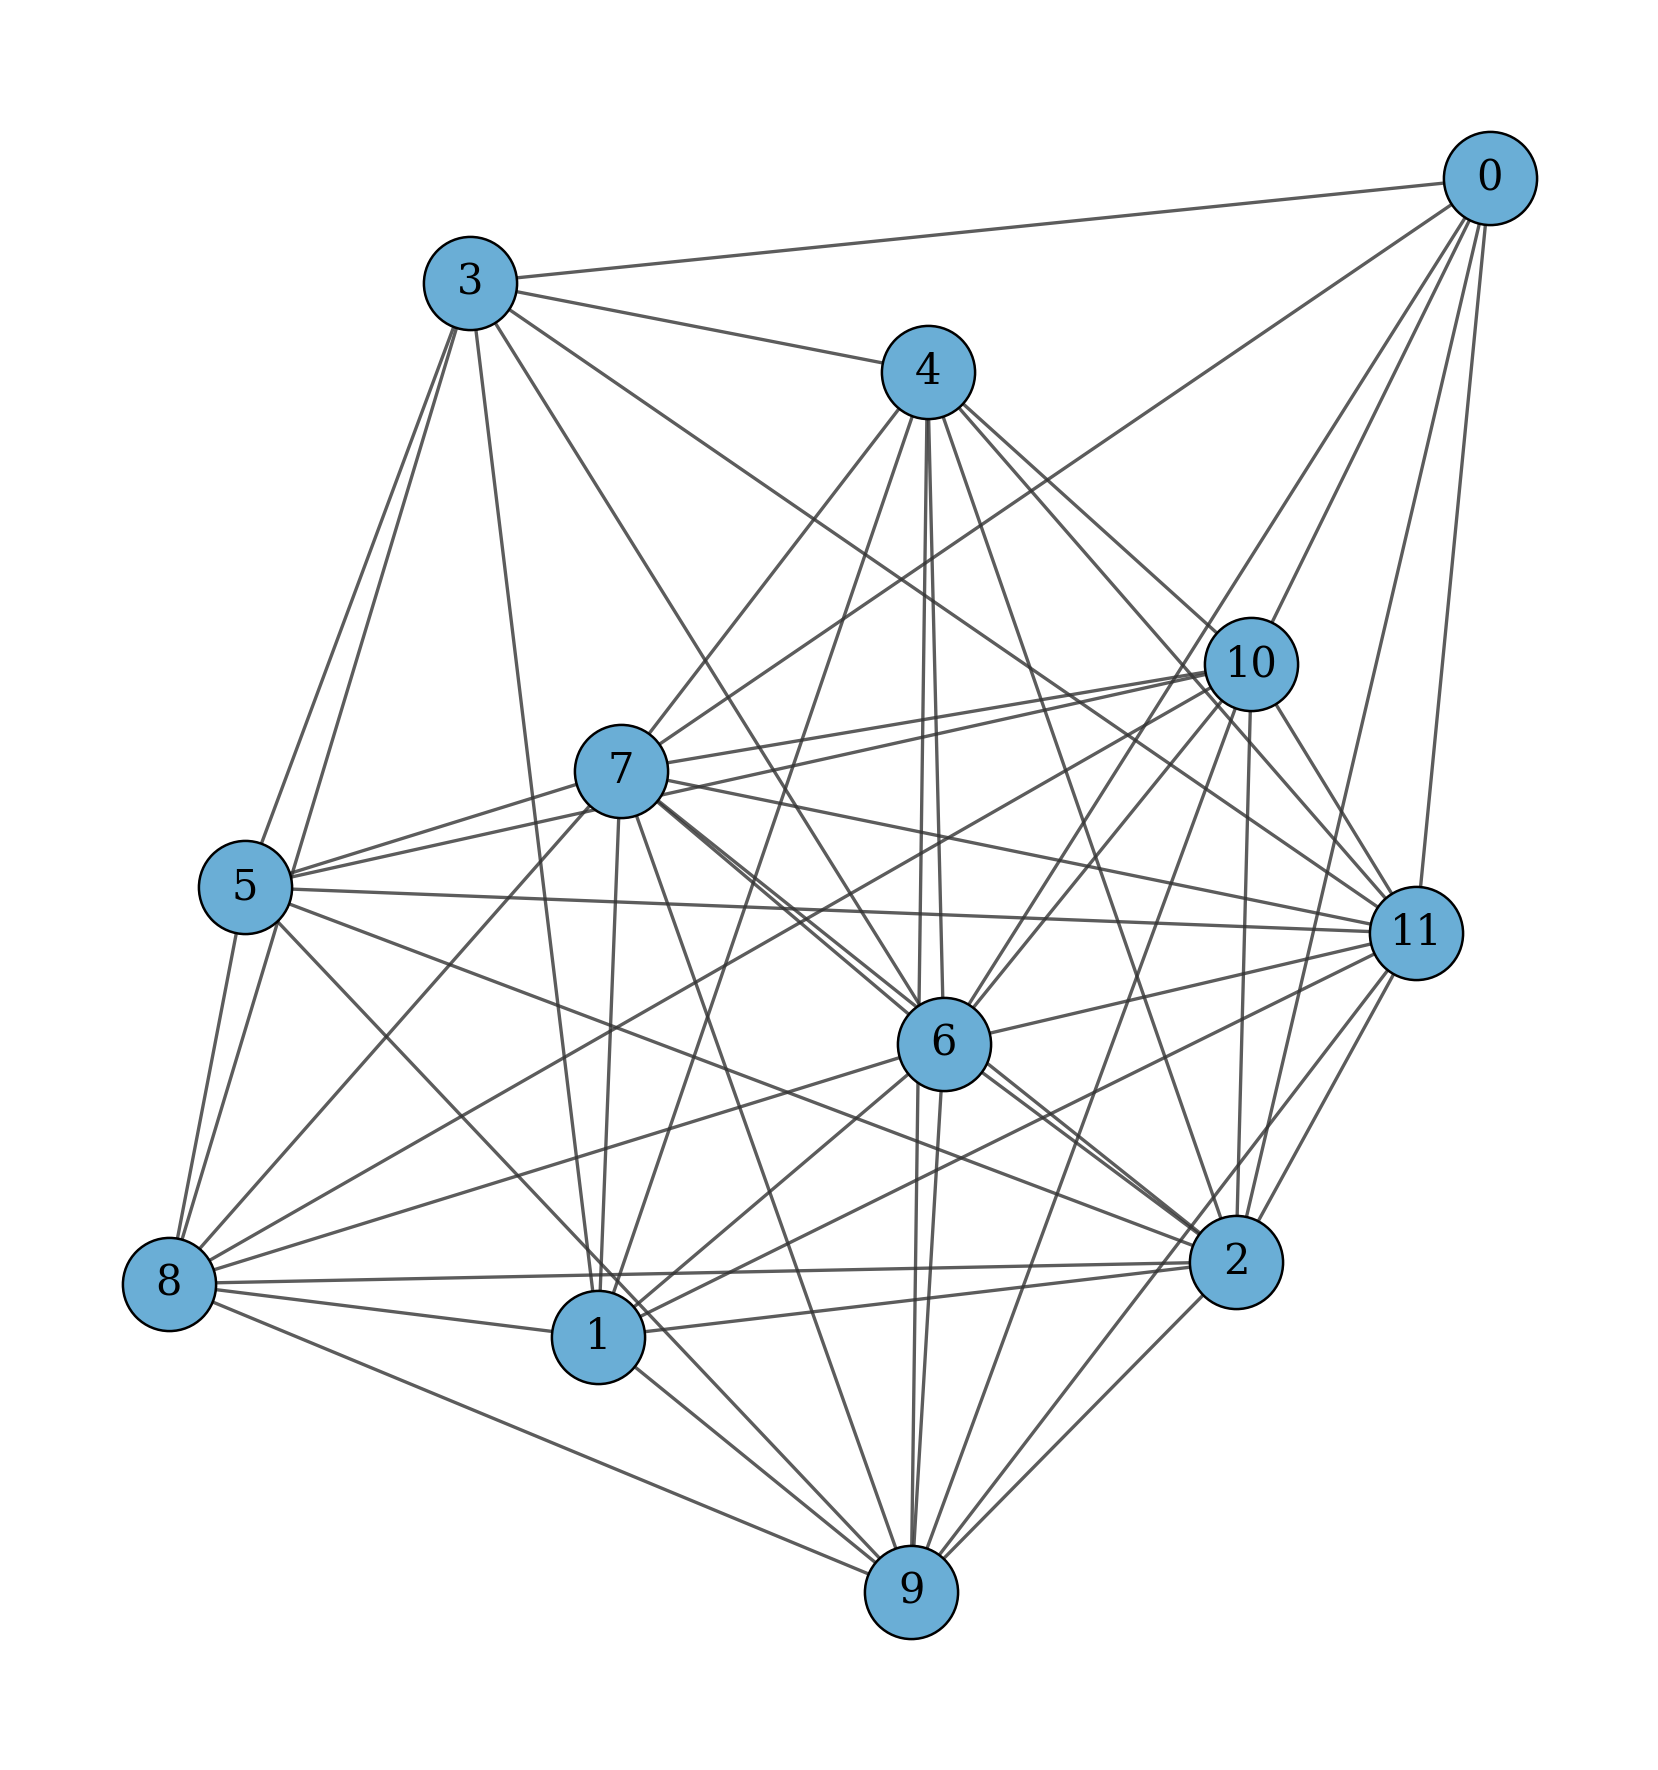

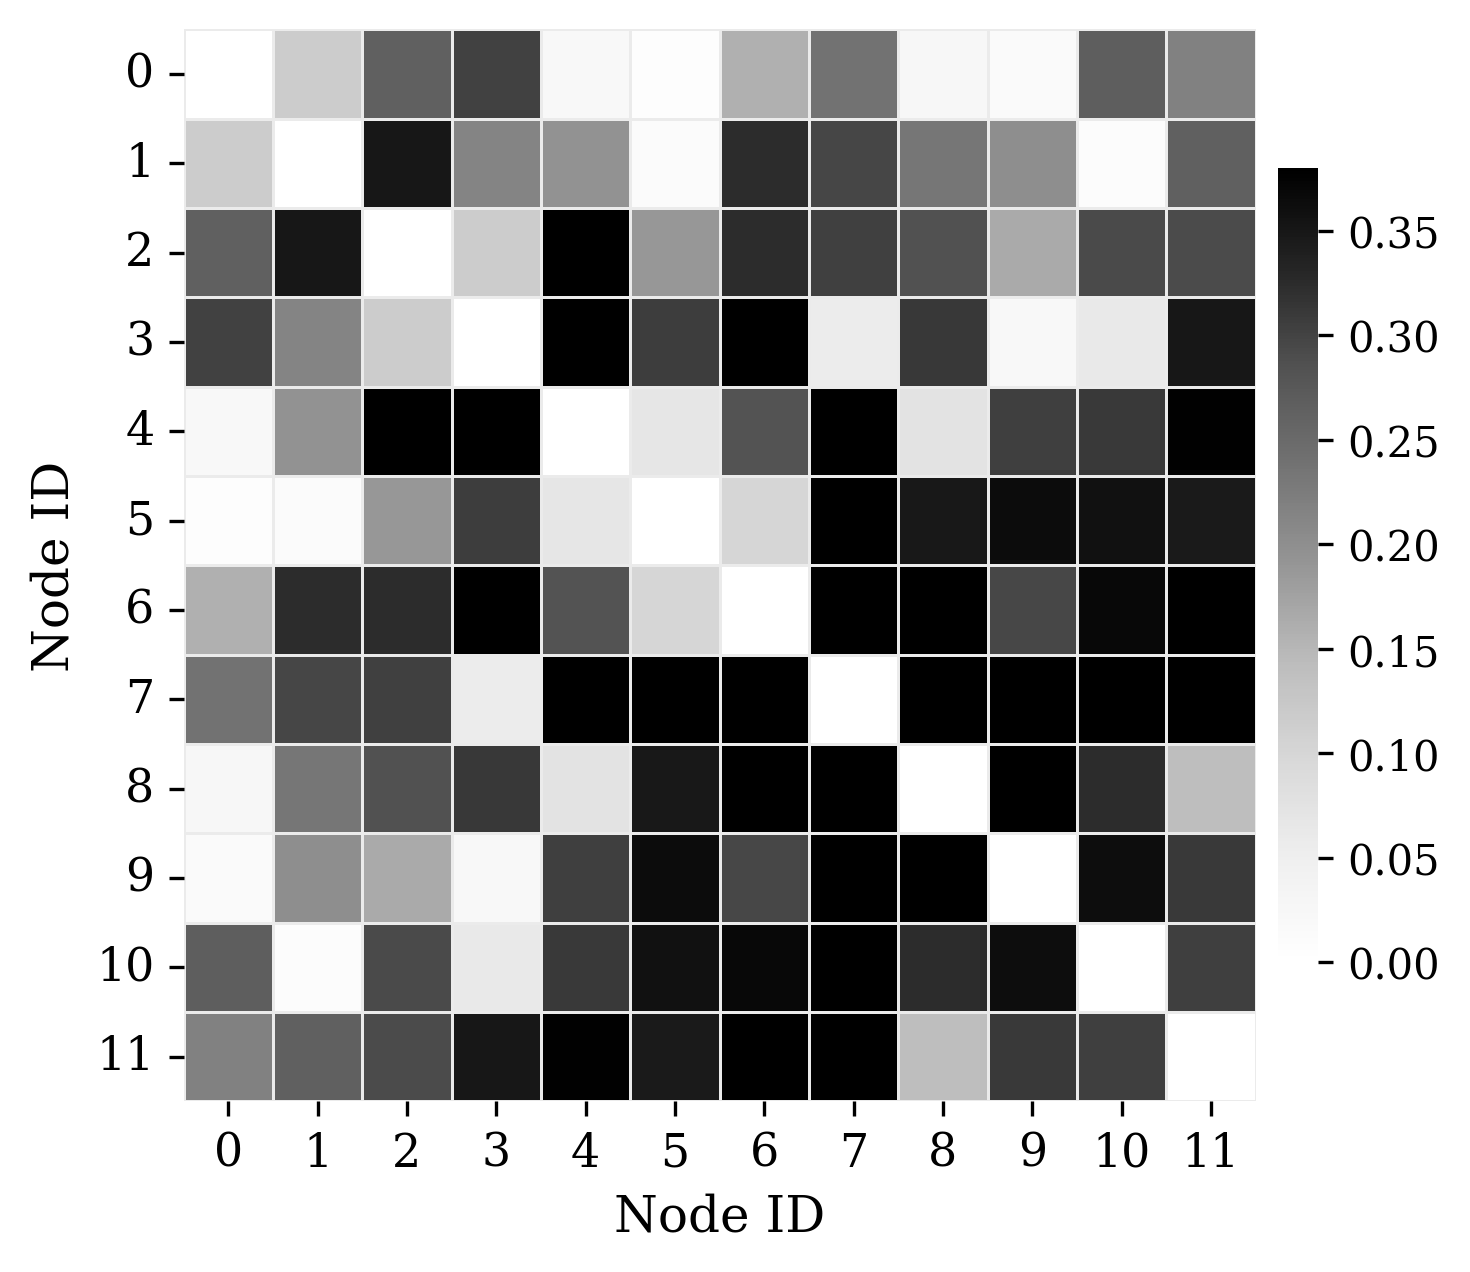

In [68]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

def plot_graph_from_prompt(prompt,
                           figsize=(6,6),
                           layout='auto',        # 'auto'|'spring'|'circular'|'kamada_kawai'|'organic'
                           node_size=500,
                           node_color='white',
                           edge_color='0.2',
                           edge_alpha=0.8,
                           color_by_degree=False,
                           show_labels=True,
                           max_labels=40,
                           seed=42,
                           jitter_scale=0.08,    # only for layout='organic'
                           iterations=200,       # spring_layout iterations for 'organic'
                           savepath=None):

    edges = re.findall(r'\((\d+)\s*,\s*(\d+)\)', prompt)
    if not edges:
        raise ValueError("no edges found in prompt")
    edges = [(int(u), int(v)) for u, v in edges]
    G = nx.Graph()
    G.add_edges_from(edges)
    nodes = sorted(G.nodes())
    N = len(nodes)
    E = G.number_of_edges()

    density = 2 * E / (N * (N - 1)) if N > 1 else 0.0
    if layout == 'auto':
        if N > 30 or density > 0.45:
            layout = 'circular'
        elif N <= 12:
            layout = 'spring'
        else:
            layout = 'kamada_kawai'

    rng = np.random.RandomState(seed)

    if layout == 'spring' or layout == 'organic':
        pos = nx.spring_layout(G, seed=seed, iterations=iterations)
        if layout == 'organic' and N > 1:
            coords = np.vstack([pos[n] for n in nodes])
            diffs = coords[None, :, :] - coords[:, None, :]
            dists = np.sqrt((diffs ** 2).sum(-1))
            np.fill_diagonal(dists, np.nan)
            nn = np.nanmean(np.nanmin(dists, axis=1))
            jitter = rng.normal(scale=max(1e-3, jitter_scale * (nn if np.isfinite(nn) else 1.0)), size=coords.shape)
            coords = coords + jitter
            pos = {n: coords[i] for i, n in enumerate(nodes)}
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    else:
        pos = nx.circular_layout(G)

    plt.figure(figsize=figsize, dpi=300)
    ax = plt.gca()
    ax.set_facecolor('white')

    if color_by_degree:
        degrees = np.array([G.degree(n) for n in nodes], dtype=float)
        cmap = plt.get_cmap('Blues')
        nc = (degrees - degrees.min()) / max(1e-9, degrees.max() - degrees.min())
        node_colors = cmap(0.3 + 0.7 * nc)
    else:
        cmap = plt.get_cmap('Blues')
        node_colors = cmap(0.5)

    nx.draw_networkx_edges(G, pos,
                           alpha=edge_alpha,
                           edge_color=edge_color,
                           width=0.8,
                           ax=ax)
    nx.draw_networkx_nodes(G, pos,
                           node_size=node_size,
                           node_color=node_colors,
                           edgecolors='black',
                           linewidths=0.6,
                           ax=ax)

    if show_labels and N <= max_labels:
        labels = {n: str(n) for n in nodes}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_family='serif', ax=ax)

    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches='tight', transparent=True)  # 推荐 .svg/.pdf
    plt.show()

def plot_adj_from_prompt(prompt, figsize=(4,4), cmap="Greys", savepath=None, max_ticks=20):
    edges = re.findall(r'\((\d+)\s*,\s*(\d+)\)', prompt)
    if not edges:
        raise ValueError("no edges found in prompt")
    edges = [(int(u), int(v)) for u, v in edges]
    print(edges)
    nodes = sorted({n for e in edges for n in e})
    idx = {n:i for i,n in enumerate(nodes)}
    N = len(nodes)

    A = np.zeros((N, N), dtype=int)
    for u, v in edges:
        i, j = idx[u], idx[v]
        if i == j:
            A[i, j] = 1
        else:
            A[i, j] = 1
            A[j, i] = 1

    from matplotlib.colors import ListedColormap
    cmap_bw = ListedColormap(['white', 'black'])  # 0 -> white, 1 -> black

    plt.figure(figsize=figsize, dpi=300)
    ax = sns.heatmap(
        A,
        cmap=cmap_bw,
        cbar=False,
        square=True,
        linewidths=0.6,
        linecolor="0.92",
        vmax=1.0,
        vmin=0.0,
        rasterized=False,
        xticklabels=False,
        yticklabels=False
    )

    # 刻度：自动稀疏以防拥挤；左侧刻度水平显示（非竖直）
    if N <= max_ticks:
        xt_pos = np.arange(N)
        yt_pos = np.arange(N)
        xt_labels = yt_labels = nodes
    else:
        step = int(np.ceil(N / max_ticks))
        xt_pos = np.arange(0, N, step)
        yt_pos = np.arange(0, N, step)
        xt_labels = [nodes[i] for i in xt_pos]
        yt_labels = [nodes[i] for i in yt_pos]

    ax.set_xticks(xt_pos + 0.5)   # heatmap cell-centered tick alignment
    ax.set_yticks(yt_pos + 0.5)
    # 把 x 轴刻度移动到上方并水平显示
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.tick_top()
    ax.set_xticklabels(xt_labels, rotation=0, ha='center', fontsize=11)
    ax.set_yticklabels(yt_labels, rotation=0, va='center', fontsize=11)

    ax.set_xlabel("Node ID")
    ax.set_ylabel("Node ID")
    ax.set_aspect('equal')
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches="tight", transparent=True)  # 推荐 .pdf 或 .svg
    plt.show()

def _find_subsequence(seq, subseq):
    if not subseq:
        return []
    L, l = len(seq), len(subseq)
    return [i for i in range(L - l + 1) if seq[i:i + l] == subseq]

def build_attention_adjacency(roi_attn, enc, g_start, g_end, tokenizer, prompt=None, agg='max'):
    """
    从 roi_attn 构建 node-level 注意力邻接矩阵。
    """
    if prompt is None:
        raise ValueError("prompt is required")
    edges = re.findall(r'\((\d+)\s*,\s*(\d+)\)', prompt)
    if not edges:
        raise ValueError("no edges found in prompt")
    nodes = sorted({int(u) for e in edges for u in e})

    enc_roi = enc.input_ids[0, g_start:g_end+1].tolist()

    node_to_token_idxs = {}
    for n in nodes:
        tok_seq = tokenizer.encode(str(n), add_special_tokens=False)
        starts = _find_subsequence(enc_roi, tok_seq)
        if starts:
            idxs = []
            for s in starts:
                idxs.extend(range(s, s + len(tok_seq)))
            node_to_token_idxs[n] = sorted(set(idxs))
        else:
            matches = []
            for i, tid in enumerate(enc_roi):
                try:
                    s = tokenizer.decode([tid]).strip()
                except Exception:
                    s = ""
                if s == str(n):
                    matches.append(i)
            node_to_token_idxs[n] = matches

    N = len(nodes)
    A = np.full((N, N), np.nan, dtype=float)

    for i_u, u in enumerate(nodes):
        idxs_u = node_to_token_idxs.get(u, [])
        for i_v, v in enumerate(nodes):
            idxs_v = node_to_token_idxs.get(v, [])
            if not idxs_u or not idxs_v:
                A[i_u, i_v] = np.nan
                continue

            vals = []
            for r in idxs_u:
                for c in idxs_v:
                    if c < r:                     # <- 关键约束（不能等于）
                        vals.append(float(roi_attn[r, c]))
            if len(vals) == 0:
                A[i_u, i_v] = np.nan
                continue

            if agg == 'max':
                A[i_u, i_v] = float(np.max(vals))
                A[i_v, i_u] = float(np.max(vals))
            elif agg == 'mean':
                A[i_u, i_v] = float(np.mean(vals))
                A[i_v, i_u] = float(np.mean(vals))
            elif agg == 'sum':
                A[i_u, i_v] = float(np.sum(vals))
                A[i_v, i_u] = float(np.sum(vals))
            else:
                raise ValueError("agg must be one of: 'max','mean','sum'")
            if i_u == i_v:
                A[i_u, i_v] = 0.0

    return nodes, A


def plot_attention_adjacency(nodes, attn_adj, figsize=(4,4), cmap="Greys",
                             vmax=None, savepath=None, max_ticks=20):
    N = len(nodes)
    plt.figure(figsize=figsize, dpi=300)
    mask = np.isnan(attn_adj)

    ax = sns.heatmap(
        np.nan_to_num(attn_adj, nan=0.0),
        mask=mask,
        cmap=cmap,
        cbar=True,
        square=True,
        linewidths=0.6,
        linecolor="0.92",
        vmax=vmax,
        vmin=0.0,
        rasterized=False,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"fraction": 0.035, "pad": 0.02, "aspect": 20, "shrink": 0.8, "format": "%.2f"}
    )

    if mask.any():
        for (i, j), m in np.ndenumerate(mask):
            if m:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color="#ffffff", lw=0))
    # 刻度稀疏化 & 水平左侧刻度
    if N <= max_ticks:
        pos = np.arange(N)
        labels = nodes
    else:
        step = int(np.ceil(N / max_ticks))
        pos = np.arange(0, N, step)
        labels = [nodes[i] for i in pos]

    ax.set_xticks(pos + 0.5)
    ax.set_yticks(pos + 0.5)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=11)
    ax.set_yticklabels(labels, rotation=0, va='center', fontsize=11)

    ax.set_xlabel("Node ID")
    ax.set_ylabel("Node ID")
    ax.set_aspect('equal')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches="tight", transparent=True)
    plt.show()


data_path = "/home/lym/data1/Datasets/GraphWiz/GraphInstruct-Test/cycle_test.json"
data = []
with open(data_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

sample_list = []
for item in data:
    spans = get_token_spans(item["input_prompt"], tokenizer)
    g_start, g_end, span_len, spans_sorted = compute_global_span(spans)
    sample_dict = {
        "input_prompt": item["input_prompt"],
        "g_start": g_start,
        "g_end": g_end,
        "span_len": span_len,
        "spans_sorted": spans_sorted
    }
    if span_len > 300 and span_len < 350:
        sample_list.append(sample_dict)
print(f"Number of samples with span length between 300 and 350: {len(sample_list)}")

sample = sample_list[1]
print(sample['input_prompt'])
sample_tokens_id = tokenizer(sample['input_prompt'])['input_ids']
print(sample_tokens_id[sample['g_start']:sample['g_end']+1])
sample_tokens = tokenizer.convert_ids_to_tokens(sample_tokens_id)
print(sample_tokens[sample['g_start']:sample['g_end']+1])

plot_adj_from_prompt(sample['input_prompt'], figsize=(5,5), cmap="Greys_r")
plot_graph_from_prompt(sample['input_prompt'], figsize=(6,6), layout='organic', color_by_degree=False)

layer, head = 12, 26
enc = tokenizer(
    sample["input_prompt"],
    return_tensors="pt",
    truncation=True,
).to(model.device)
with torch.no_grad():
    out = model(enc.input_ids, output_attentions=True, use_cache=False)
attn_np = np.stack(
    [a[0].to(torch.float32).detach().cpu().numpy() for a in out.attentions],
    axis=0
)
full_attn = attn_np[layer, head]
roi_attn = full_attn[sample["g_start"]:sample["g_end"] + 1, sample["g_start"]:sample["g_end"] + 1]

# 使用示例（在该 notebook 中已有变量）
nodes, attn_adj = build_attention_adjacency(roi_attn, enc, sample['g_start'], sample['g_end'], tokenizer, prompt=sample['input_prompt'], agg='sum')
plot_attention_adjacency(nodes, attn_adj, figsize=(5,5), cmap="Greys", vmax=0.38)

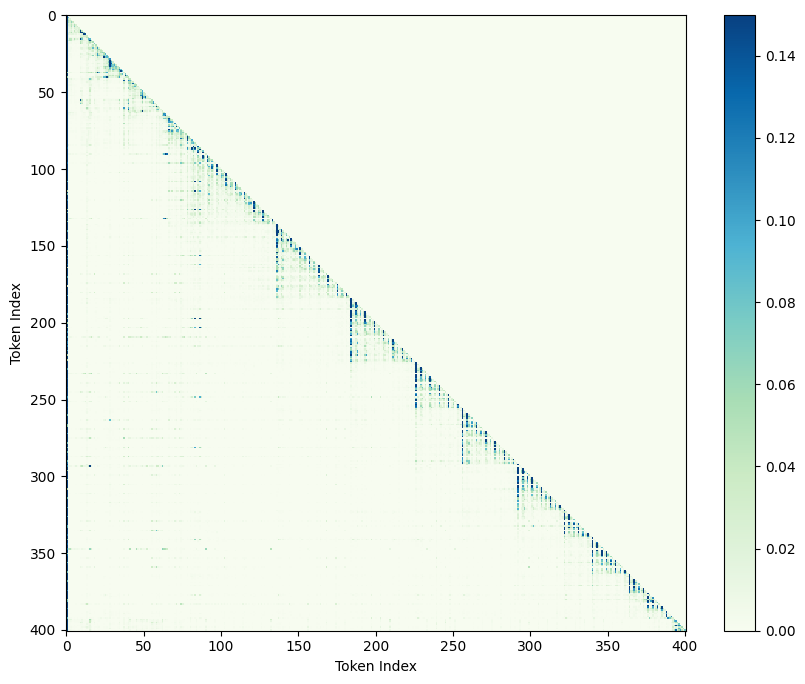

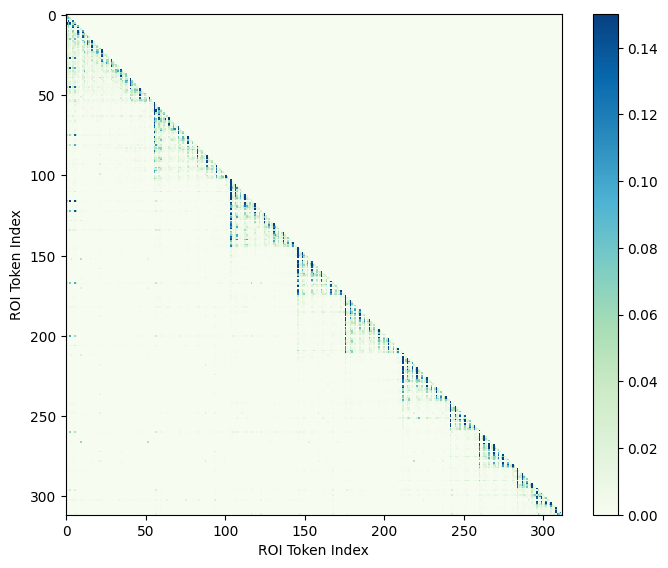

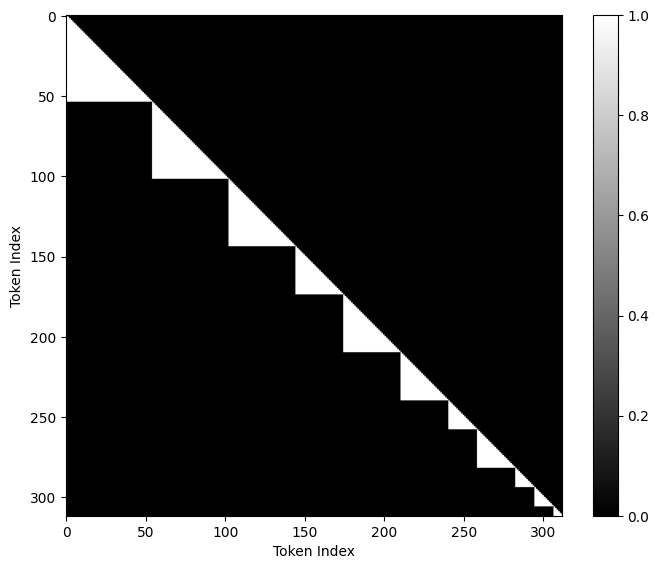

In [3]:
import matplotlib.pyplot as plt

# 绘制 full_attn 热力图
# full_attn[:, 0] = 0
plt.figure(figsize=(10, 8))
# plt.title("full_attn Heatmap")
plt.imshow(full_attn, aspect='auto', cmap='GnBu', interpolation='nearest', vmax=0.15)
plt.colorbar()
plt.xlabel("Token Index")
plt.ylabel("Token Index")
plt.show()

# 绘制 roi_attn 热力图
plt.figure(figsize=(8, 6.5))
# plt.title("roi_attn Heatmap")
plt.imshow(roi_attn, aspect='auto', cmap='GnBu', interpolation='nearest', vmax=0.15)
plt.colorbar()
plt.xlabel("ROI Token Index")
plt.ylabel("ROI Token Index")
plt.show()

# 绘制 ideal_mask 热力图
plt.figure(figsize=(8, 6.5))
# plt.title("ideal_mask Heatmap")
plt.imshow(ideal_mask, aspect='auto', cmap='gray')
plt.colorbar()
plt.xlabel("Token Index")
plt.ylabel("Token Index")
plt.show()

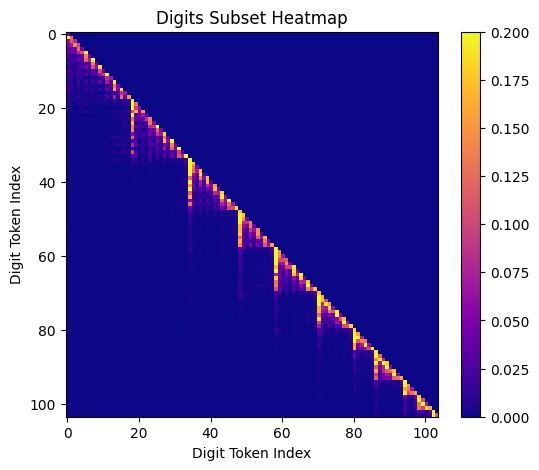

In [4]:
import re
from matplotlib.colors import LinearSegmentedColormap

# 1. 提取所有数字字符串
numbers = sorted(set(map(int, re.findall(r'\d+', sample_input))))
number_tokens = [str(n) for n in numbers]

# 2. 获取roi区域的token ids
enc_roi_ids = enc.input_ids[0, g_start:g_end+1].tolist()

# 3. 获取所有数字token的id（只取第一个token，适用于单token数字）
digit_token_ids = [tokenizer.encode(num, add_special_tokens=False)[0] for num in number_tokens]

# 4. 找到这些token id在roi中的索引
num_token_indices = [i for i, tid in enumerate(enc_roi_ids) if tid in digit_token_ids]

# 5. 提取对应行列的子矩阵
roi_digits_attn = roi_attn[np.ix_(num_token_indices, num_token_indices)]

custom_cmap = LinearSegmentedColormap.from_list('my_cmap', ['#f2f2f2', '#be5c37'])
soft_red = LinearSegmentedColormap.from_list(
    'soft_red', ['#fff5f0', '#fcbba1', '#e74c3c']
)
soft_orange = LinearSegmentedColormap.from_list(
    'soft_orange', ['#fff7ec', '#fdcc8a', '#ff9800']
)
soft_green = LinearSegmentedColormap.from_list(
    'soft_green', ['#f7fcf5', '#b2e2b4', '#41b883']
)
soft_blue = LinearSegmentedColormap.from_list(
    'soft_blue', ['#f7fbff', '#a6c8e0', '#3498db']
)
custom_cmap = LinearSegmentedColormap.from_list('my_cmap', ["#dbe0e1", '#ebbfc2', '#e28187'])
# custom_cmap = LinearSegmentedColormap.from_list('my_cmap', ['#fbf9fa', '#afb7db', '#507aaf'])
# 6. 绘制更小的子集热力图
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.title("Digits Subset Heatmap")
plt.imshow(roi_digits_attn, aspect='auto', cmap='plasma', interpolation='nearest', vmax=0.2)
plt.colorbar()
plt.xlabel("Digit Token Index")
plt.ylabel("Digit Token Index")
plt.show()


Sequential_maps = ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
    'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
    'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn']
# OrRd, GnBu

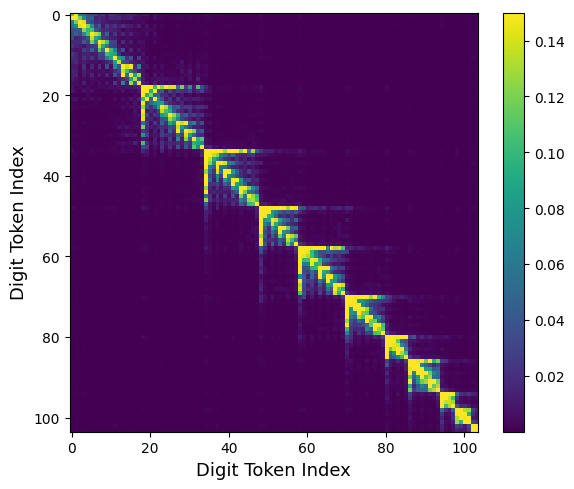

[320, 15, 11, 220, 18, 8, 320, 15, 11, 220, 605, 8, 320, 15, 11, 220, 22, 8, 320, 15, 11, 220, 20, 8, 320, 15, 11, 220, 23, 8, 320, 15, 11, 220, 806, 8, 320, 15, 11, 220, 17, 8, 320, 15, 11, 220, 16, 8, 320, 15, 11, 220, 19, 8, 320, 16, 11, 220, 21, 8, 320, 16, 11, 220, 24, 8, 320, 16, 11, 220, 17, 8, 320, 16, 11, 220, 19, 8, 320, 16, 11, 220, 22, 8, 320, 16, 11, 220, 23, 8, 320, 16, 11, 220, 20, 8, 320, 16, 11, 220, 605, 8, 320, 17, 11, 220, 20, 8, 320, 17, 11, 220, 24, 8, 320, 17, 11, 220, 605, 8, 320, 17, 11, 220, 22, 8, 320, 17, 11, 220, 18, 8, 320, 17, 11, 220, 23, 8, 320, 17, 11, 220, 806, 8, 320, 18, 11, 220, 605, 8, 320, 18, 11, 220, 19, 8, 320, 18, 11, 220, 21, 8, 320, 18, 11, 220, 20, 8, 320, 18, 11, 220, 22, 8, 320, 19, 11, 220, 24, 8, 320, 19, 11, 220, 20, 8, 320, 19, 11, 220, 806, 8, 320, 19, 11, 220, 605, 8, 320, 19, 11, 220, 21, 8, 320, 19, 11, 220, 22, 8, 320, 20, 11, 220, 23, 8, 320, 20, 11, 220, 605, 8, 320, 20, 11, 220, 806, 8, 320, 20, 11, 220, 21, 8, 320, 20, 11, 2

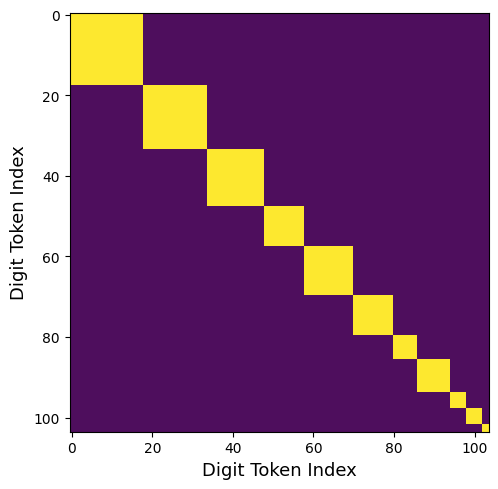

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import re

# 1. 对称化注意力子矩阵
roi_digits_attn_sym = (roi_digits_attn + roi_digits_attn.T)

plt.figure(figsize=(6, 5))
# plt.title("Symmetric Digits Attention", fontsize=16)
plt.imshow(roi_digits_attn_sym, aspect='auto', cmap='viridis', interpolation='nearest', vmax=0.15)
plt.colorbar()
plt.xlabel("Digit Token Index", fontsize=13)
plt.ylabel("Digit Token Index", fontsize=13)
plt.tight_layout()
plt.show()


# 假设 num_token_indices, roi_digits_attn_sym 已有
# 1. 获取 roi 区域所有数字token的顺序列表
enc_roi_ids = enc.input_ids[0, g_start:g_end+1].tolist()
roi_digits_token_list = []
for tid in num_token_indices:
    token_str = tokenizer.decode([enc_roi_ids[tid]]).strip()
    roi_digits_token_list.append(token_str)

N = len(roi_digits_token_list)
gt = np.zeros((N, N), dtype=int)

print(enc_roi_ids)
print(local_spans)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

N = len(num_token_indices)
gt = np.zeros((N, N), dtype=int)

# num_token_indices 是数字token在roi中的索引
for span_start, span_end in local_spans:
    # 找到属于当前span的数字token子集的索引
    indices_in_span = [k for k, idx in enumerate(num_token_indices) if span_start <= idx <= span_end]
    for i in indices_in_span:
        for j in indices_in_span:
            gt[i, j] = 1

plt.figure(figsize=(6,5))
# plt.title("Local Span-based Adjacency", fontsize=16)
# plt.imshow(gt, aspect='auto', cmap='viridis', interpolation='nearest')
plt.imshow(gt, cmap='viridis', interpolation='nearest', alpha=0.95)
# sns.heatmap(gt, cmap='viridis', linewidths=0.01, linecolor='gray', square=True, cbar=True)
# plt.colorbar(fraction=0.046, pad=0.04)
plt.xlabel("Digit Token Index", fontsize=13)
plt.ylabel("Digit Token Index", fontsize=13)
plt.tight_layout()
plt.show()